# Results of SPARC reorientation experiments

This notebook reproduces the statistical analysis of the deep-learning reorientation networks trained across Philips (source) and Siemens (target) domains: source-only, joint, and transfer-learning conditions, ensemble vs. individual-model prediction, and rotation-averaging strategy (chordal / quaternion / geodesic) comparisons.

Part of the `sparc` package, by Arnaud Boutillon (arnaud.boutillon@kcl.ac.uk)

**On data.** This notebook operates on `csv/reo_*.csv` and `csv/cohort.csv`m de-identified, subject-level tables of reorientation metrics, not raw imaging data.

## Setup

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf

from scipy.stats import ttest_rel
from scipy.spatial.transform import Rotation

sns.set_theme(style="darkgrid")
warnings.filterwarnings("ignore", category=FutureWarning)

notebook_dir = os.path.abspath("./")
csv_dir = os.path.join(notebook_dir, "csv")
plot_dir = os.path.join(notebook_dir, "plot")

## Utilities

- `load_df` loads and concatenates one `reo_<domain>.csv` per condition, converting every geodesic-distance column from radians to degrees.
- `convert_pvalue_to_asterisks` standard significance-stars convention.
- `plot_metrics` shared boxplot-with-significance-brackets figure, used for both the ensemble- and individual-prediction comparisons below.

In [2]:
def load_df(csv_dir, domain_col, domains, domains_labels):
    """Load and concatenate one reo_<domain>.csv per condition,
    labelling each with domains_labels[i] under domain_col, and
    converting every column whose name contains "GD" from radians
    (as stored) to degrees.
    """
    dfs = []
    for i, (domain, domain_label) in enumerate(zip(domains, domains_labels)):
        if domain is None:
            dfs.append(pd.DataFrame({domain_col: [i]}))
        else:
            domain_df = pd.read_csv(os.path.join(csv_dir, f"reo_{domain}.csv"))
            domain_df[domain_col] = domain_label
            dfs.append(domain_df)

    df = pd.concat(dfs, ignore_index=True)
    for column in df:
        if "GD" in column:
            df[column] = round(180 / np.pi * df[column], 4)
    return df

In [3]:
def convert_pvalue_to_asterisks(pvalue):
    """Standard significance-stars convention: **** <=0.0001,
    *** <=0.001, ** <=0.01, * <=0.05, else "ns" (not significant)."""
    if pvalue <= 0.0001:
        return "****"
    elif pvalue <= 0.001:
        return "***"
    elif pvalue <= 0.01:
        return "**"
    elif pvalue <= 0.05:
        return "*"
    return "ns"

In [4]:
def plot_metrics(dfs):
    """Boxplot of each metric (rows) across domains (columns of
    subplots = source/target dataframes passed in), annotated with
    per-group mean +/- std and pairwise significance brackets from a
    linear mixed-effects model (subject_id as random-effects group),
    Bonferroni-corrected for the number of pairwise comparisons drawn
    in each panel.
    """
    fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey="row")
    fig.suptitle(title)

    for i, (df, _domains, _domains_labels, _comparisons) in enumerate(zip(dfs, domains, domains_labels, comparisons)):
        for j, (metric_col, metric_label) in enumerate(zip(metric_cols, metric_labels)):
            # Distributions
            sns.boxplot(ax=axes[j,i], data=df, x=domain_col, y=metric_col, hue=domain_col, width=0.4, legend=False)
            y_range = y_lims[j][1] - y_lims[j][0]

            # Per-group mean +/- std annotation
            for k, (domain, domain_label) in enumerate(zip(_domains, _domains_labels)):
                if domain is None:
                    continue
                group = df[df[domain_col] == domain_label][metric_col]
                mu = group.mean()
                std = group.std()
                axes[j,i].text(k, group.min() - 0.1*y_range, f"{mu:.2f} \u00b1 {std:.2f}", ha="center", va="center", fontsize=10)

            # Pairwise significance: linear mixed-effects model, subject_id
            # as random-effects group (accounts for repeated, correlated
            # samples per subject), Bonferroni-corrected across the
            # comparisons drawn in this panel.
            l = 0
            for k, (g1, g2) in enumerate(_comparisons):
                formula = f"{metric_col} ~ C({domain_col}, Treatment('{g1}'))"
                _df = df[(df[domain_col] == g1) | (df[domain_col] == g2)]
                lme_model = smf.mixedlm(formula=formula, data=_df, groups=_df[groups_col]).fit(reml=False)
                p = lme_model.pvalues[f"C({domain_col}, Treatment('{g1}'))[T.{g2}]"]
                stars = convert_pvalue_to_asterisks(p * len(_comparisons))  # Bonferroni correction

                if stars == "ns":
                    continue
                # Bracket annotation
                x1 = _domains_labels.index(g1)
                x2 = _domains_labels.index(g2)
                y_max = 1.1 * df[metric_col].max() + (l+1) * 0.085 * y_range
                offset = 0.05 * y_range
                axes[j,i].plot([x1, x1, x2, x2], [y_max, y_max + offset, y_max + offset, y_max], color='black')
                axes[j,i].text((x1+x2)/2, y_max + offset + 0.01, stars, ha='center')
                l += 1

            # Titles, labels, ticks
            if j == 0 and i == 0:
                axes[j,i].set_title("Source domain")
            elif j == 0 and i == 1:
                axes[j,i].set_title("Target domain")
            if i == 0:
                axes[j,i].set_ylabel(metric_label)
            else:
                axes[j,i].set_ylabel(None)
            if j == 1:
                axes[j,i].set_xticks(range(len(_domains_labels)), labels=[l if l is not None else "" for l in _domains_labels])
            else:
                axes[j,i].set_xticks([])
            axes[j,i].set_xlabel(None)
            axes[j,i].set_xlim([-.5, 3.5])
            axes[j,i].set_ylim(y_lims[j])

    fig.tight_layout()
    output_dir = os.path.dirname(plot_path)
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")

## 1. Cohorts information

In [5]:
df_path = os.path.join(csv_dir, "cohort.csv")

df = pd.read_csv(df_path)
df = df.dropna(subset=["reo"])
src_df = df[df["domain"] == "Philips"]
tgt_df = df[df["domain"] == "Siemens"]

print("Source domain (Philips scanner):")
print(f"Number of subjects: {len(src_df.index)}")
print("Reorientation data split:")
print(f"Train: {len(src_df[src_df['reo'] == 'Train'].index)} / Test: {len(src_df[src_df['reo'] == 'Test'].index)}")

print("Target domain (Siemens scanner):")
print(f"Number of subjects: {len(tgt_df.index)}")
print("Reorientation data split:")
print(f"Train: {len(tgt_df[tgt_df['reo'] == 'Train'].index)} / Test: {len(tgt_df[tgt_df['reo'] == 'Test'].index)}")

Source domain (Philips scanner):
Number of subjects: 112
Reorientation data split:
Train: 91 / Test: 21
Target domain (Siemens scanner):
Number of subjects: 39
Reorientation data split:
Train: 32 / Test: 7


## 2. Reorientation networks comparison

Four training conditions are compared: **Source** (Philips-only), **Joint** (both domains trained together), **Target** (Siemens-only), and **Transfer** (Philips-pretrained, fine-tuned on Siemens), evaluated on each domain's held-out test set.

In [6]:
domain_col = "domain"

domains_src = ["philips", "joint_to_philips"]
domains_src_labels = ["Source", "Joint"]
comparisons_src = [("Source", "Joint")]
groups_col = "subject_id"

domains_tgt = ["philips_to_siemens", "joint_to_siemens", "siemens", "siemens_transfer"]
domains_tgt_labels = ["Source", "Joint", "Target", "Transfer"]
comparisons_tgt = [("Source", "Joint"), ("Source", "Target"), ("Source", "Transfer"),
                   ("Joint", "Target"), ("Joint", "Transfer"),
                   ("Target", "Transfer")]

domains = [domains_src, domains_tgt]
domains_labels = [domains_src_labels, domains_tgt_labels]
comparisons = [comparisons_src, comparisons_tgt]

In [7]:
src_df = load_df(csv_dir, domain_col, domains_src, domains_src_labels)
tgt_df = load_df(csv_dir, domain_col, domains_tgt, domains_tgt_labels)
dfs = [src_df, tgt_df]

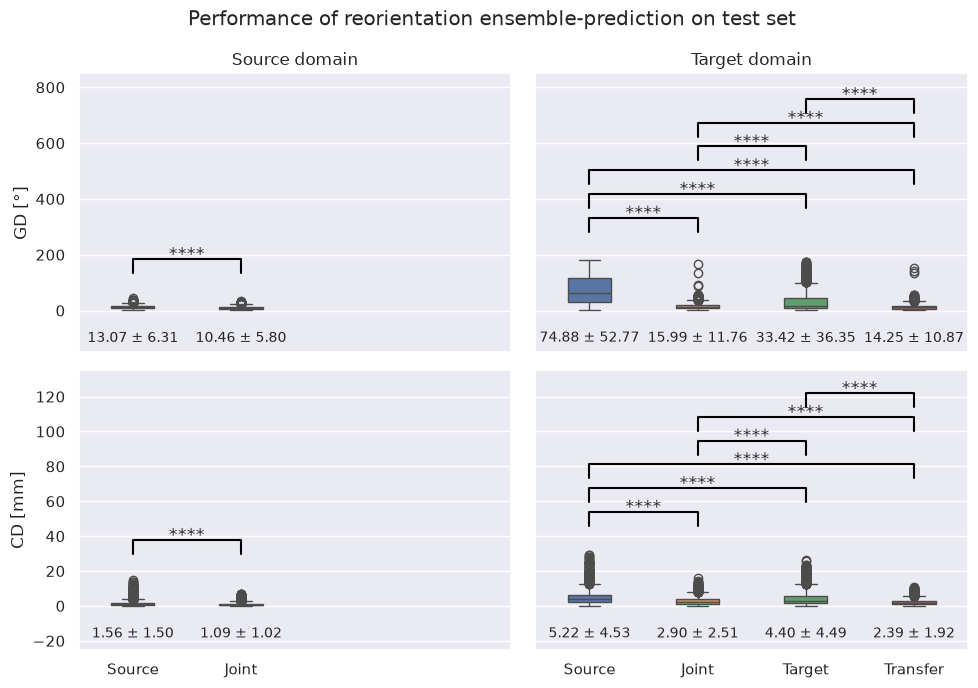

In [8]:
title = "Performance of reorientation ensemble-prediction on test set"
metric_cols = ["GD_EP", "CD_EP"]
metric_labels = ["GD [\u00b0]", "CD [mm]"]
y_lims = [(-150, 850), (-25, 135)]
plot_path = os.path.join(plot_dir, "reo_metrics_EP.png")
plot_metrics(dfs)

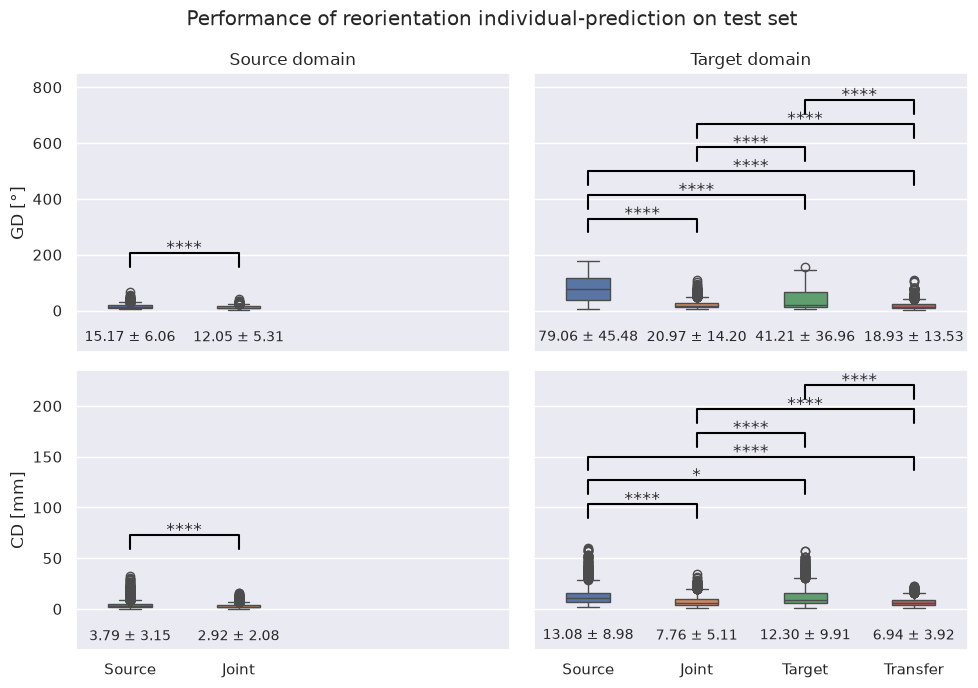

In [9]:
title = "Performance of reorientation individual-prediction on test set"
metric_cols = ["GD_IP", "CD_IP"]
metric_labels = ["GD [\u00b0]", "CD [mm]"]
y_lims = [(-150, 850), (-40, 235)]
plot_path = os.path.join(plot_dir, "reo_metrics_IP.png")
plot_metrics(dfs)

In [10]:
# Transfer-ensemble vs. transfer-individual
metric_cols = ["GD", "CD"]
print("Transfer-ensemble vs. Transfer-individual")
for metric_col in metric_cols:
    y1 = tgt_df[tgt_df[domain_col] == "Transfer"][metric_col + "_EP"]
    y2 = tgt_df[tgt_df[domain_col] == "Transfer"][metric_col + "_IP"]
    stat, p = ttest_rel(y1, y2)
    stars = convert_pvalue_to_asterisks(p)
    if stars == "ns":
        continue
    print(metric_col, stars)

Transfer-ensemble vs. Transfer-individual
GD ****
CD ****


In [11]:
# Transfer-ensemble rotation-averaging strategy: Chordal vs. Quaternion and Geodesic
metric_cols = ["Q", "G"]
metric_labels = ["Quaternion", "Geodesic"]
for metric_col, metric_label in zip(metric_cols, metric_labels):
    y1 = tgt_df[tgt_df[domain_col] == "Transfer"]["GD_EP"]
    y2 = tgt_df[tgt_df[domain_col] == "Transfer"]["GD_EP_" + metric_col]
    mean1 = y1.mean()
    mean2 = y2.mean()
    std1 = y1.std()
    std2 = y2.std()
    stat, p = ttest_rel(y1, y2)
    stars = convert_pvalue_to_asterisks(p)
    print(f"Chordal vs. {metric_label}", stars)
    print(f"{mean1:.2f} ± {std1:.2f}")
    print(f"{mean2:.2f} ± {std2:.2f}")

Chordal vs. Quaternion ****
14.25 ± 10.87
16.65 ± 15.33
Chordal vs. Geodesic ****
14.25 ± 10.87
16.29 ± 13.52


In [12]:
ir_df_path = os.path.join(csv_dir, "reo_inter_rater.csv")
ir_df = pd.read_csv(ir_df_path)
y = round(180 / np.pi * ir_df["GD_IR"], 4)
mean = y.mean()
std = y.std()
print("Inter-rater GD:", f"{mean:.2f} ± {std:.2f}")

Inter-rater GD: 7.87 ± 2.86


## 3. Performance analysis

### 3.a. Angle magnitude sampling distribution

For a uniformly distributed random rotation, the rotation angle magnitude has probability density $p(|\theta|) = \dfrac{2}{\pi}\sin^2\!\left(\dfrac{|\theta|}{2}\right)$ on $|\theta| \in [0, \pi]$ and favours large rotations near $\pi$. 

In [13]:
def sample_angles(n, r_range=None, restricted=False):
    np.random.seed(42)
    if r_range is None:
        r_range = [1, 1, 1]

    # Euler angles in radians
    a = 2 * np.pi * np.random.rand(n)  # 0, 2pi
    b = np.arccos(2 * np.random.rand(n) - 1)  # 0, pi
    if restricted:
        c = np.pi * np.random.rand(n)  # 0, pi
    else:
        c = np.pi * (2 * np.random.rand(n) - 1)  # -pi, pi
    a *= r_range[0]
    b *= r_range[1]
    c *= r_range[2]
    r = np.stack([a, b, c], -1)

    R = Rotation.from_euler("ZXZ", r)
    rotvec = R.as_rotvec()
    angle = np.linalg.norm(rotvec, axis=1)

    return angle


def true_pdf(theta):
    """Theoretical PDF of rotation-angle magnitude under a Haar-
    uniform random rotation"""
    
    return 2 / np.pi * np.sin(theta / 2) ** 2

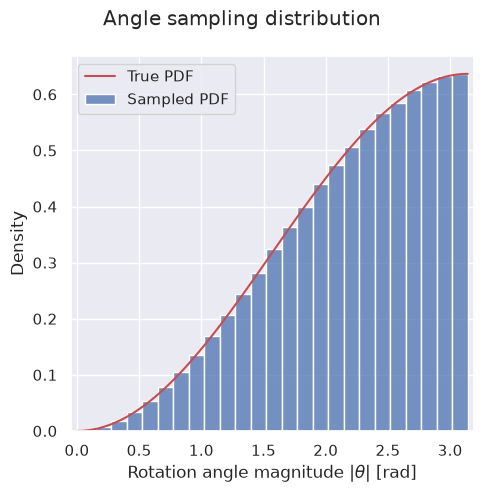

In [14]:
plot_path = os.path.join(plot_dir, "reo_angle_sampling.png")

angles = sample_angles(n=int(1e6))
df = pd.DataFrame(data={"angles": angles})

x = np.linspace(0, np.pi, 100)
pdf = true_pdf(x)  

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
fig.suptitle("Angle sampling distribution")

sns.histplot(ax=ax, data=df, x="angles", bins=25, stat="density", label="Sampled PDF")
ax.plot(x, pdf, c="r", label="True PDF")
ax.set_xlim(-0.05, np.pi + 0.05)
ax.set_xlabel(r"Rotation angle magnitude $|\theta|$ [rad]")
ax.legend(loc="upper left")

fig.tight_layout()
output_dir = os.path.dirname(plot_path)
os.makedirs(output_dir, exist_ok=True)
plt.savefig(plot_path, dpi=300, bbox_inches="tight")

### 3.b. Subject-wise performance

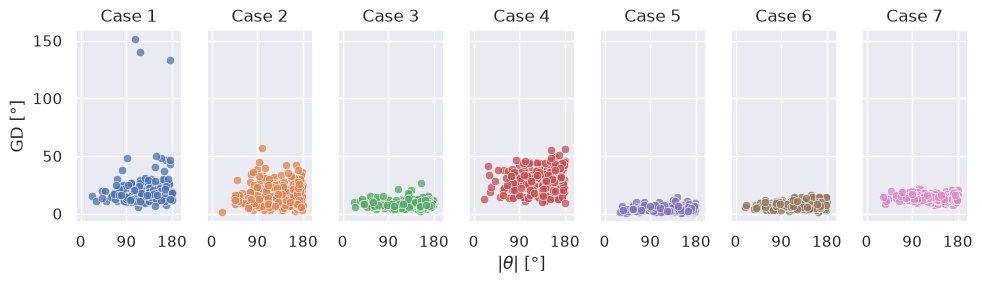

In [15]:
df_path = os.path.join(csv_dir, "reo_siemens_transfer.csv")
plot_path = os.path.join(plot_dir, "reo_siemens_transfer_subjectwise.png")

df = pd.read_csv(df_path)

x_col = "angle"
metric_col = "GD_EP"
metric_label = r"GD [$\degree$]"
subj_col = "subject_id"
subj_ids = sorted(set(df[subj_col].tolist()))
n = len(subj_ids)

df["angle"] *= 180 / np.pi
df["GD_EP"] *= 180 / np.pi

palette = sns.color_palette()

fig, axes = plt.subplots(1, n, figsize=(10, 3), sharey="row", sharex=True)

for i, subj_id in enumerate(subj_ids):
    df_subj = df[df[subj_col] == subj_id]
    sns.scatterplot(ax=axes[i], data=df_subj, x=x_col, y=metric_col, alpha=0.75, color=palette[i])

    axes[i].set_title(f"Case {i+1}")
    axes[i].set_xticks(ticks=[0, 90, 180], labels=[0, 90, 180])
    axes[i].set_xlim(-10, 200)
    if i == n // 2:
        axes[i].set_xlabel(r"$|\theta|$ [$\degree$]")
    else:
        axes[i].set_xlabel(None)
    if i == 0:
        axes[i].set_ylabel(metric_label)
    else:
        axes[i].set_ylabel(None)

fig.tight_layout()
output_dir = os.path.dirname(plot_path)
os.makedirs(output_dir, exist_ok=True)
plt.savefig(plot_path, dpi=300, bbox_inches="tight")